In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from AttackInfo import attack_info, Sensors, Actuators, stage_map
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_normal = pd.read_parquet("../../Dataset/SWaT_Dataset_Normal_v1.parquet")
df_attack = pd.read_parquet("../../Dataset/SWaT_Dataset_Attack_v1.parquet")

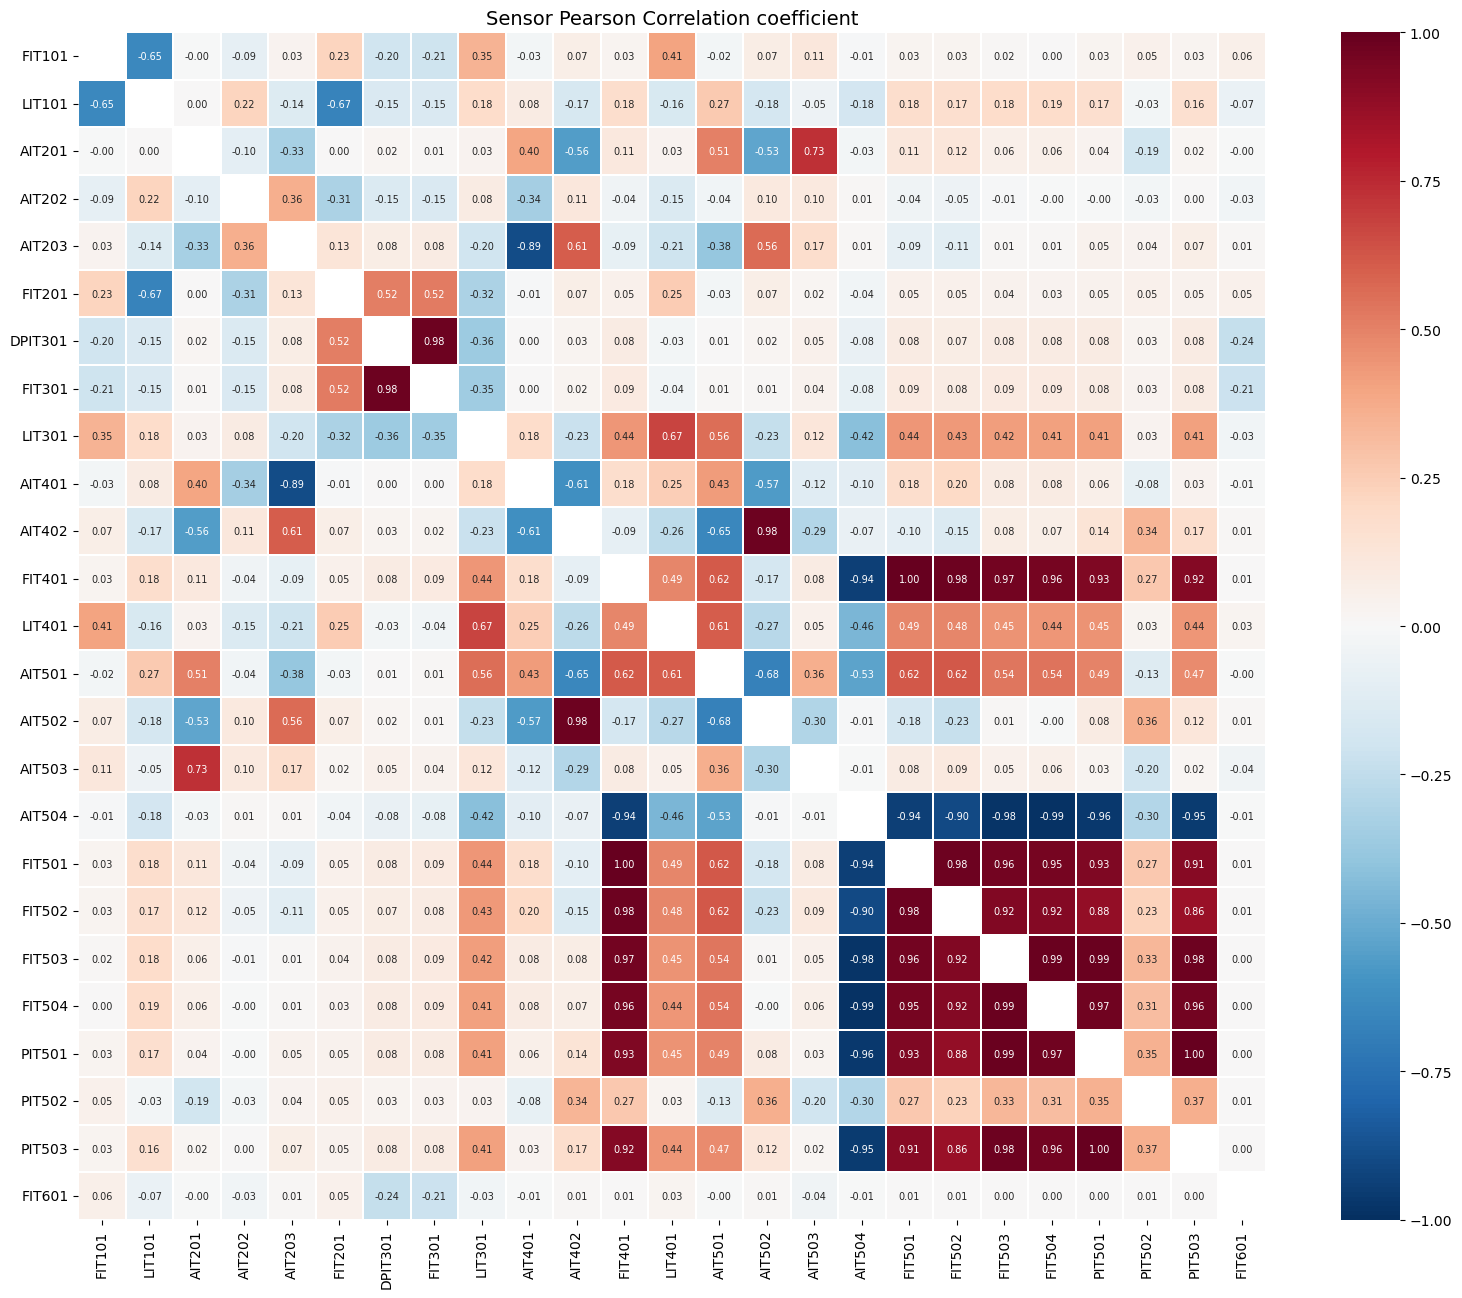


高度相關 (|r| > 0.7) 感測器對共 32 組：


,Sensor A,Sensor B,r
5,FIT401,FIT501,0.9997
31,PIT501,PIT503,0.9987
27,FIT503,PIT501,0.9911
26,FIT503,FIT504,0.9908
14,AIT504,FIT504,-0.9881
28,FIT503,PIT503,0.9841
3,AIT402,AIT502,0.9801
13,AIT504,FIT503,-0.9790
17,FIT501,FIT502,0.9786
6,FIT401,FIT502,0.9781


In [6]:
# 7.1 Normal 資料感測器相關係數矩陣
corr_normal = df_normal[Sensors].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.zeros_like(corr_normal, dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(corr_normal, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            annot_kws={'size': 7}, linewidths=0.3)
ax.set_title('Sensor Pearson Correlation coefficient', fontsize=14)
plt.tight_layout()
plt.show()

# 高度相關（|r| > 0.7）的感測器對
high_corr = []
for i in range(len(Sensors)):
    for j in range(i+1, len(Sensors)):
        r = corr_normal.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append({'Sensor A': Sensors[i], 'Sensor B': Sensors[j], 'r': round(r, 4)})

print(f"\n高度相關 (|r| > 0.7) 感測器對共 {len(high_corr)} 組：")
display(pd.DataFrame(high_corr).sort_values('r', key=abs, ascending=False))

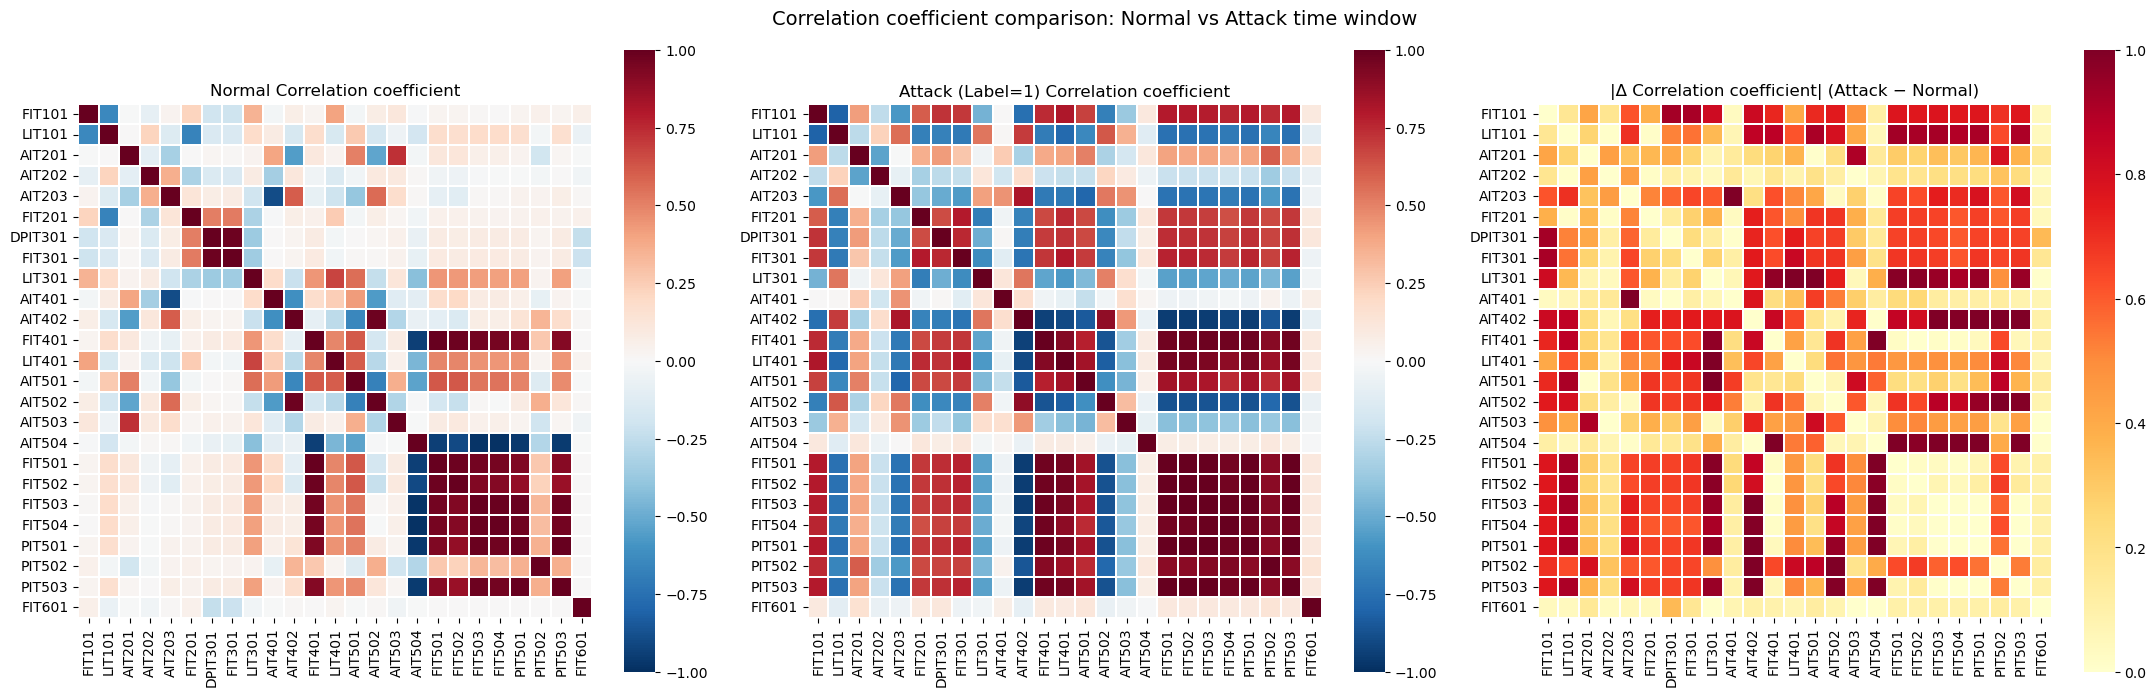


相關係數變化最大的 10 組感測器對：
AIT203  AIT401    1.3383
LIT301  LIT401    1.2434
AIT402  PIT502    1.1925
AIT502  PIT502    1.1469
AIT402  PIT503    1.1247
        PIT501    1.0893
AIT504  FIT504    1.0632
        FIT503    1.0548
        PIT501    1.0387
        PIT503    1.0292


In [9]:
# 7.2 Normal vs Attack 相關係數差異（Delta Correlation）
corr_attack = df_attack[df_attack['Label'] == 1][Sensors].corr()
delta_corr  = (corr_attack - corr_normal).abs()

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

sns.heatmap(corr_normal,  ax=axes[0], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar=True, annot=False, linewidths=0.2)
axes[0].set_title('Normal Correlation coefficient')

sns.heatmap(corr_attack, ax=axes[1], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar=True, annot=False, linewidths=0.2)
axes[1].set_title('Attack (Label=1) Correlation coefficient')

sns.heatmap(delta_corr,   ax=axes[2], cmap='YlOrRd', vmin=0, vmax=1,
            square=True, cbar=True, annot=False, linewidths=0.2)
axes[2].set_title('|Δ Correlation coefficient| (Attack − Normal)')

plt.suptitle('Correlation coefficient comparison: Normal vs Attack time window', fontsize=14)
plt.tight_layout()
plt.show()

# 最大相關性變化的感測器對
delta_flat = delta_corr.where(np.triu(np.ones(delta_corr.shape), k=1).astype(bool)).stack()
delta_top = delta_flat.sort_values(ascending=False).head(10)
print("\n相關係數變化最大的 10 組感測器對：")
print(delta_top.round(4).to_string())

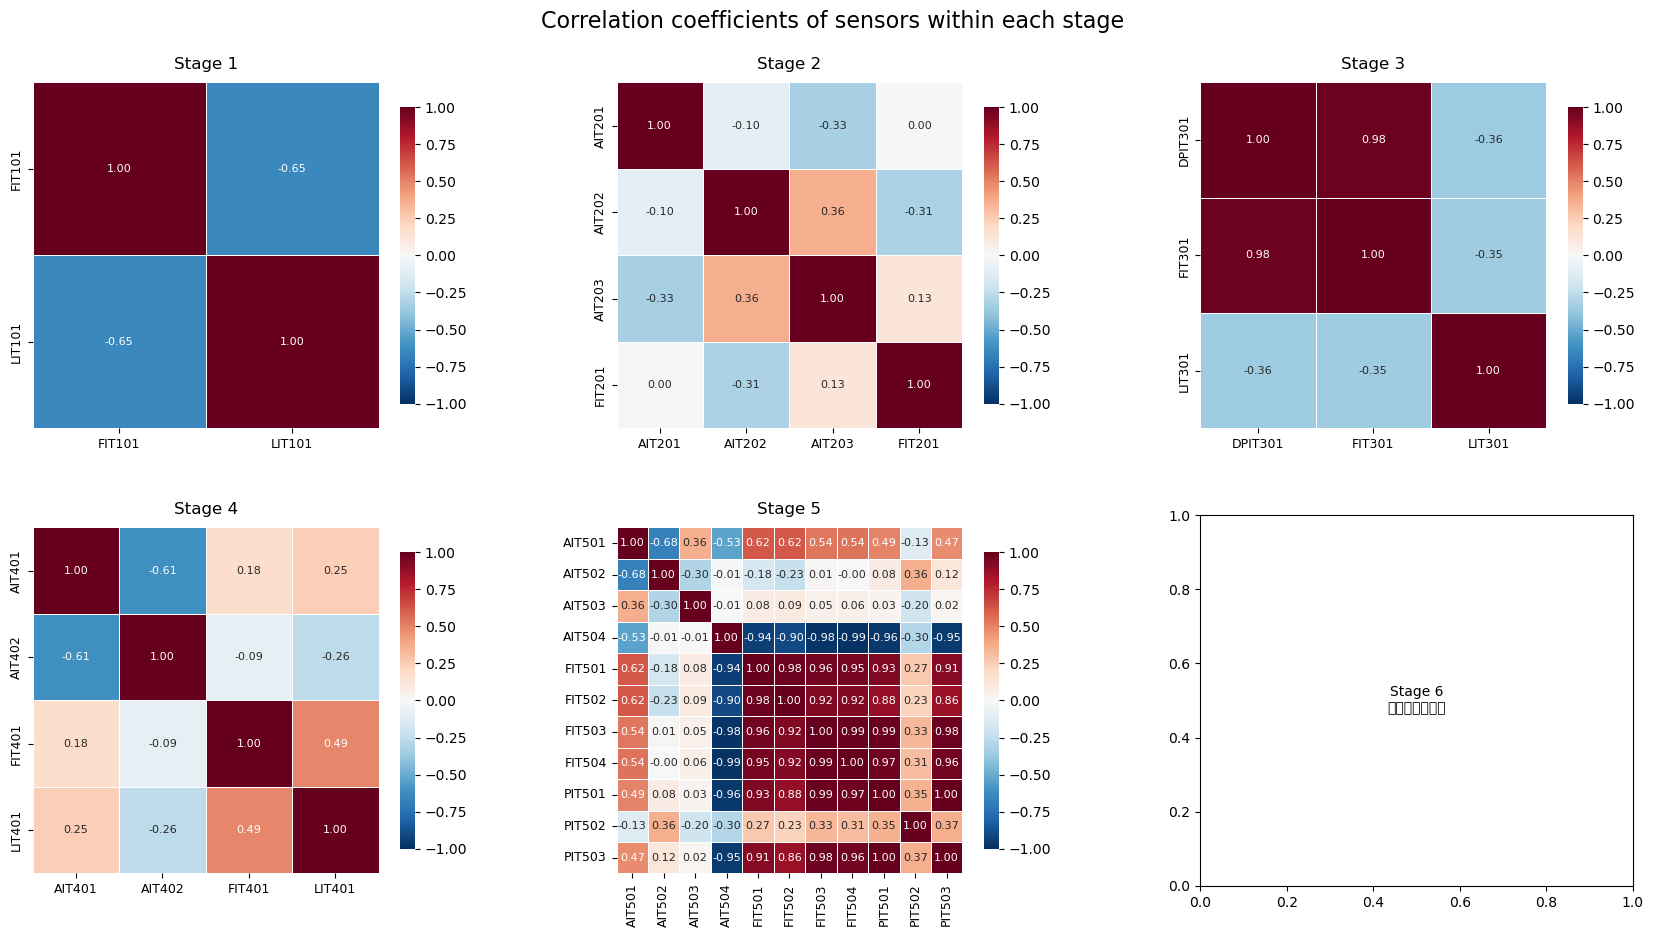

In [27]:
# 7.3 各 Stage 內部感測器相關性（Normal 資料）
# 7.3 各 Stage 內部感測器相關性（Normal 資料）
fig, axes = plt.subplots(2, 3, figsize=(20, 12)) # 稍微放大畫布寬度與高度
axes = axes.flatten()

for s_idx, (stage, info) in enumerate(stage_map.items()):
    sensors = [s for s in info['sensors'] if s in df_normal.columns] # 確保欄位存在
    
    if len(sensors) < 2:
        axes[s_idx].text(0.5, 0.5, f'Stage {stage}\n感測器數量不足', ha='center', va='center')
        continue
        
    corr_stage = df_normal[sensors].corr()
    
    # 優化重點：
    # 1. cbar=False (選用): 如果想節省空間，可以考慮只在最後一格放 colorbar，或縮小它
    # 2. xticklabels/yticklabels: 設定字體大小避免重疊
    sns.heatmap(corr_stage, ax=axes[s_idx], cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, annot=True, fmt='.2f', square=True,
                annot_kws={'size': 8}, # 縮小熱圖內數字
                linewidths=0.5,
                cbar_kws={'shrink': 0.8}) # 縮小側邊 colorbar 長度
    
    axes[s_idx].set_title(f'Stage {stage}', fontsize=12, pad=10)
    axes[s_idx].tick_params(axis='both', which='major', labelsize=9) # 縮小座標軸刻度字體

# 核心修正：手動調整子圖間距
# wspace: 子圖寬度間距, hspace: 子圖高度間距
plt.subplots_adjust(left=0.1, bottom=0.2, right=0.9, top=0.88, wspace=0.35, hspace=0.2)

plt.suptitle('Correlation coefficients of sensors within each stage', fontsize=16, y=0.93)

# 隱藏最後一個沒用到的空白子圖 (Stage 6 若無數據)
if len(stage_map) < len(axes):
    for i in range(len(stage_map), len(axes)):
        axes[i].axis('off')

plt.show()